In [1]:
# we are using the gaia public access data from relaease 3
from astroquery.gaia import Gaia
import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from astropy.table import Table
import os
from sklearn.model_selection import train_test_split

# Documentation: https://astroquery.readthedocs.io/en/latest/gaia/gaia.html
# https://scikit-learn.org/stable/model_selection.html

/Users/ishnatripathi/Documents/ML_projects/aivenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


The DataLink service will not be available on Thursday 10 September between 09:45 and 14:00 due to maintenance.


            SOURCE_ID         ra        dec  parallax  parallax_error  \
0  137338313799478912  45.081119  35.303676  0.053364        0.355962   
1  137338764771167488  45.136893  35.330263  0.245917        0.091144   
2  137338863555334144  45.130132  35.344342  0.821378        0.297745   
3  137339516390355200  45.080338  35.336283  0.270650        0.305999   
4  137339688189079296  45.112700  35.373226  0.533166        0.059716   

   phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag     bp_rp      ruwe  
0        19.469528         19.822273         19.021521  0.800753  0.980401  
1        17.087906         17.395216         16.588539  0.806677  1.116324  
2        19.211094         20.527819         18.047226  2.480593  1.026195  
3        19.190176         19.956011         18.480755  1.475256  1.041864  
4        16.330654         16.822475         15.676068  1.146407  1.063868  
(1000, 10)
Index(['SOURCE_ID', 'ra', 'dec', 'parallax', 'parallax_error',
       'phot_g_mean_mag',

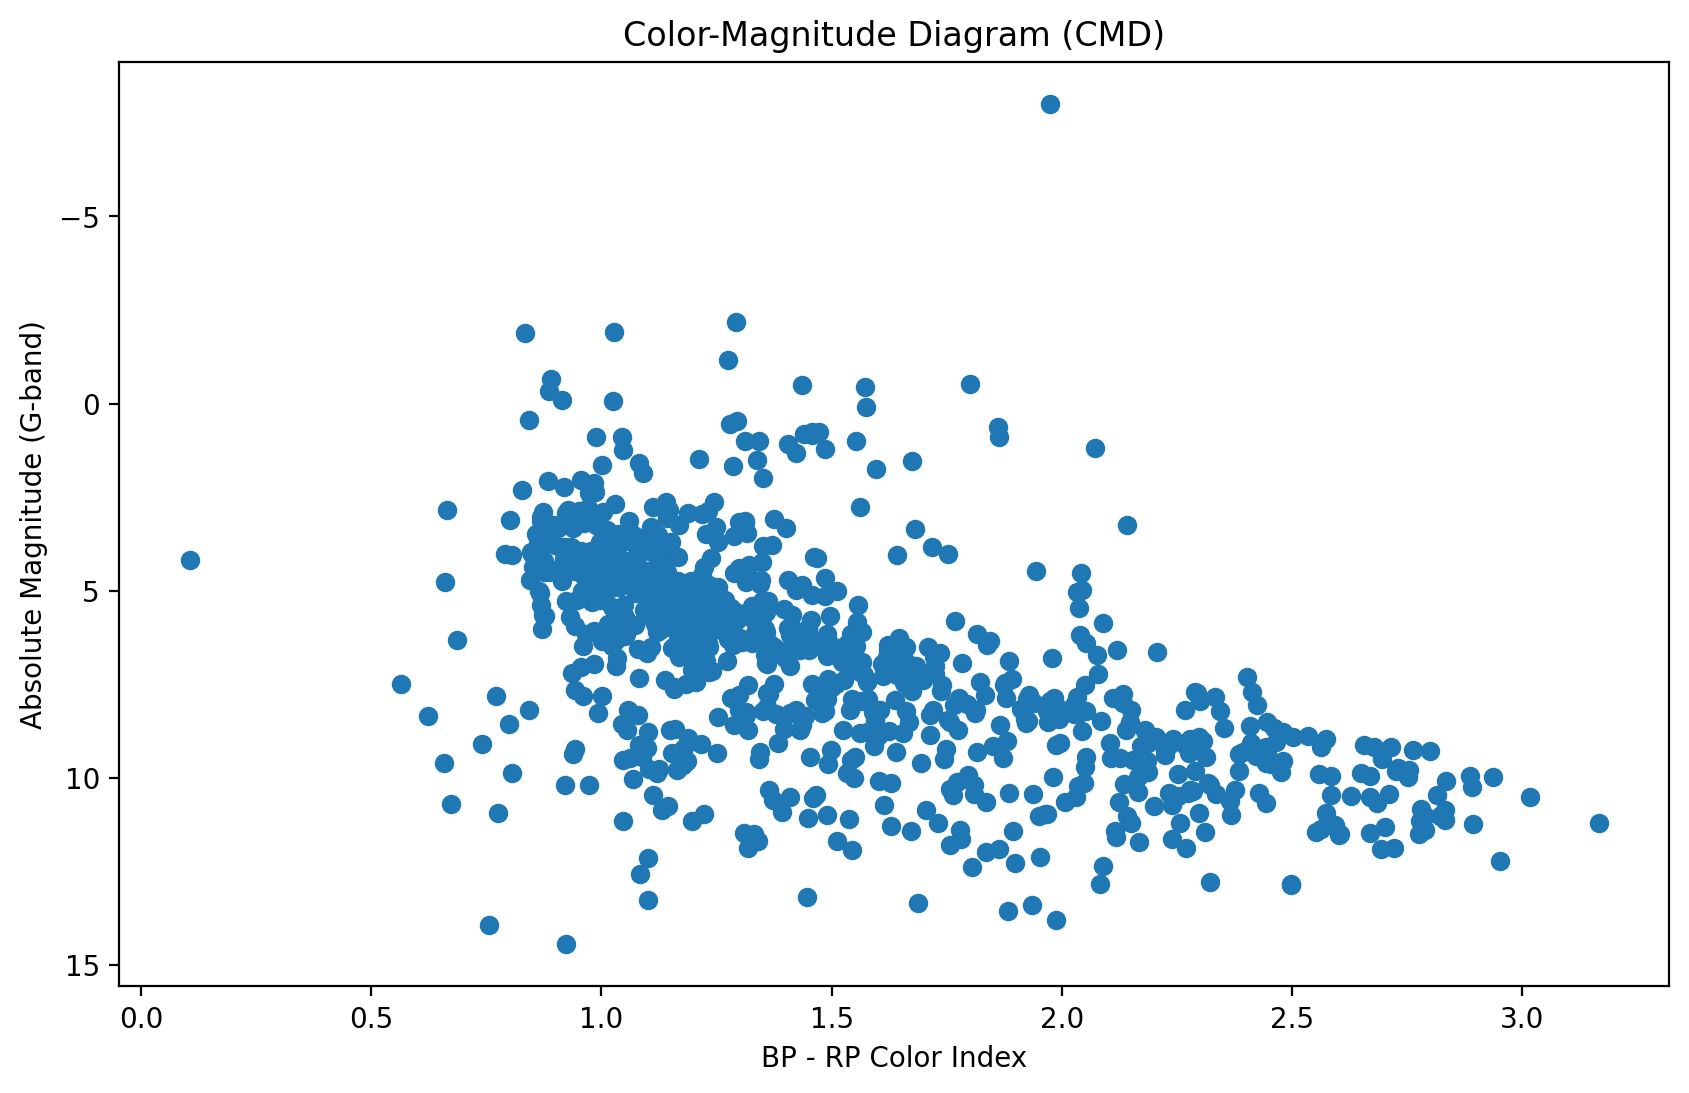

In [2]:
# Load your Gaia file
table = Table.read("/Users/ishnatripathi/Documents/ML_projects/gaia_ml/data/512f093d-abcd-11f1-b67b-bc97e148b76b-O-result.vot", format="votable")

# Convert to pandas
df = table.to_pandas()

print(df.head())
print(df.shape)
print(df.columns)

ra = df['ra']
dec = df['dec']
parallax = df['parallax']
parallax_error = df['parallax_error']
g_mag = df['phot_g_mean_mag']
bp_mag = df['phot_bp_mean_mag']
bp_rp = df['bp_rp']
source_id = df['SOURCE_ID']

# masking invalid parallax values
valid_mask = (parallax > 0) & (parallax_error > 0)
ra = ra[valid_mask]
dec = dec[valid_mask]
parallax = parallax[valid_mask]
parallax_error = parallax_error[valid_mask]
bp_mag = bp_mag[valid_mask]
g_mag = g_mag[valid_mask]
bp_rp = bp_rp[valid_mask]
source_id = source_id[valid_mask]

# Absolute magnitude calculation
# Absolute magnitude = apparent magnitude - 5 * (log10(distance) - 1)
# Distance in parsecs = 1 / (parallax in arcseconds)
distance_pc = 1 / (parallax / 1000)  # Convert parallax
m_g = g_mag - 5 * (np.log10(distance_pc) - 1)  # Calculate absolute magnitude

plt.figure(figsize=(10, 6), dpi = 200)
plt.scatter(bp_rp, m_g)
plt.xlabel('BP - RP Color Index')
plt.ylabel('Absolute Magnitude (G-band)')
plt.title('Color-Magnitude Diagram (CMD)')
plt.gca().invert_yaxis()  # Invert y-axis for CMD
plt.show()

In [3]:
# StarHorse data processing
starhorse = pd.read_csv("/Users/ishnatripathi/Documents/ML_projects/gaia_ml/data/StarHorse_data.csv")

# Merge Gaia and StarHorse data on SOURCE_ID
gaia = pd.read_csv("/Users/ishnatripathi/Documents/ML_projects/gaia_ml/data/gaia_data.csv")

# Merge the two datasets on SOURCE_ID
data = starhorse.merge(gaia, on="SOURCE_ID", how="inner")

# Distance-corrected absolute magnitude
data["M_G"] = (data["phot_g_mean_mag"]- 5 * np.log10(data["dist50"])- 10)

# Approximate Gaia extinction coefficients
A_G_coeff = 0.789
E_BP_RP_coeff = 1.289

data["A_G"] = A_G_coeff * data["av50"]

data["E_BP_RP"] = E_BP_RP_coeff * data["av50"]

# Dereddened absolute magnitude
M_G_0 = data["M_G"] - data["A_G"]

# Dereddened colour
BP_RP_0 = data["bp_rp"] - data["E_BP_RP"]

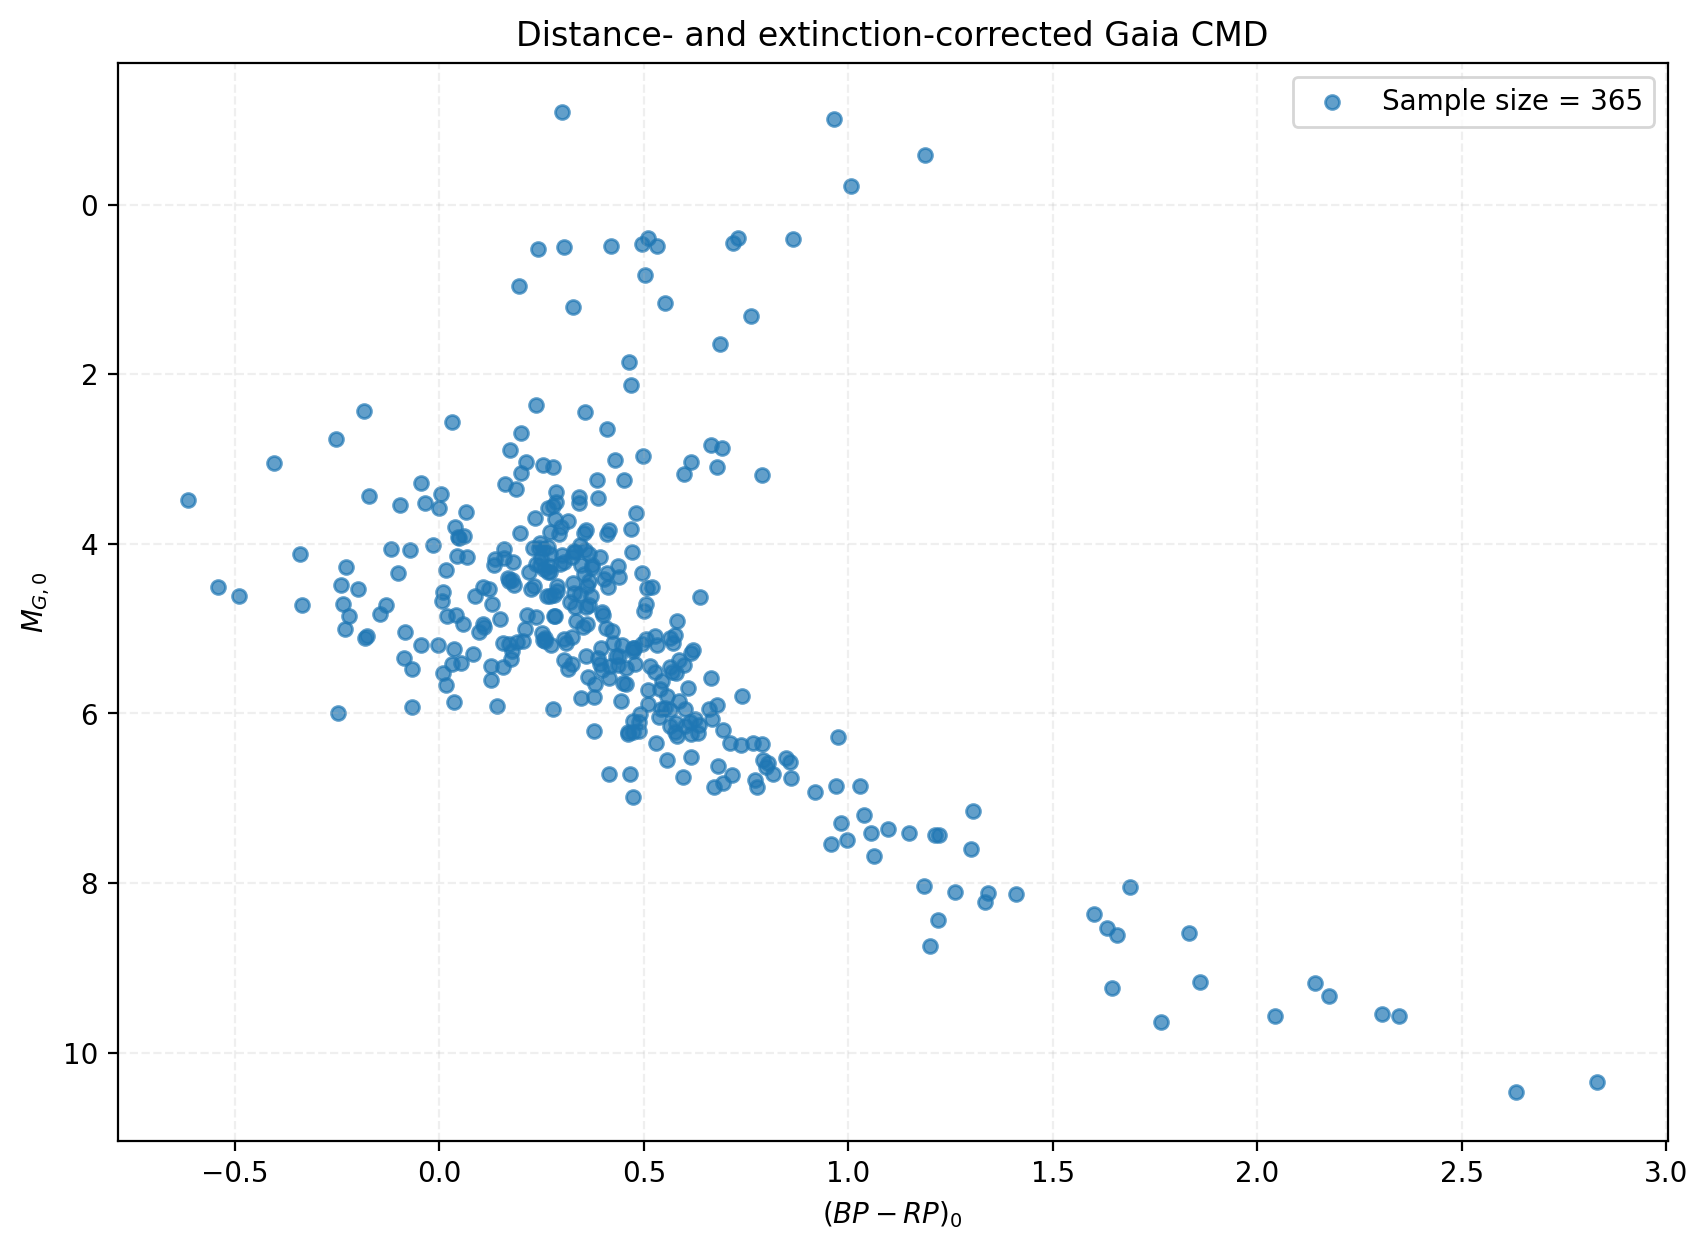

Sample size: 365


In [4]:
# Plotting the dereddened CMD
plt.figure(figsize=(10, 7), dpi=200)

plt.scatter(BP_RP_0, M_G_0, s=25, alpha=0.7, label = "Sample size = " + str(len(data)))
plt.gca().invert_yaxis()
plt.xlabel(r"$(BP-RP)_0$")
plt.ylabel(r"$M_{G,0}$"); plt.legend()
plt.title("Distance- and extinction-corrected Gaia CMD")
plt.grid(ls = '--', alpha=0.2); plt.show()
print(f"Sample size: {len(data)}")

In [5]:
# Section 2 of the paper: Prepare the Gaia–StarHorse training dataset

print("Number of stars in the Gaia–StarHorse training dataset:", len(data))
print("Number of stars:", len(data))

target = "teff50"


feature_columns = ["phot_g_mean_mag", "bp_rp", "parallax"]

## This model will learn Gaia observations -> T_effective (from StarHorse)

ml_data = data[feature_columns + [target]].copy()
ml_data = ml_data.replace([np.inf, -np.inf], np.nan)

ml_data = ml_data.dropna() # Remove rows missing a feature or target
ml_data = ml_data[ml_data["parallax"] > 0]

print("Stars available for ML:", len(ml_data))
print("Stars after positive-parallax cut:", len(ml_data))

#from sklearn.model_selection import train_test_split

X = ml_data[feature_columns]
y = ml_data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training stars:", len(X_train))
print("Testing stars:", len(X_test))
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Number of stars in the Gaia–StarHorse training dataset: 365
Number of stars: 365
Stars available for ML: 365
Stars after positive-parallax cut: 365
Training stars: 292
Testing stars: 73
Feature matrix shape: (365, 3)
Target shape: (365,)


In [6]:
# Section 3: Baseline XGBoost regression

from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create the model
model = XGBRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Predict the unseen test stars
y_pred = model.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE:  {mae:.2f} K")
print(f"RMSE: {rmse:.2f} K")
print(f"R²:   {r2:.3f}")

MAE:  181.30 K
RMSE: 231.84 K
R²:   0.872


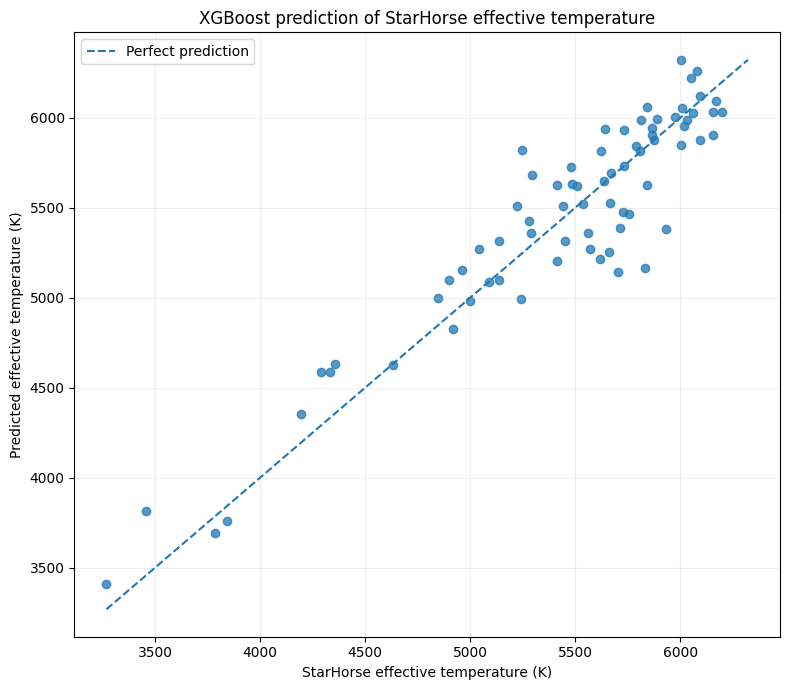

In [7]:
plt.figure(figsize=(8, 7))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.75
)

# Perfect-prediction line
lower = min(y_test.min(), y_pred.min())
upper = max(y_test.max(), y_pred.max())

plt.plot(
    [lower, upper],
    [lower, upper],
    linestyle="--",
    label="Perfect prediction"
)

plt.xlabel("StarHorse effective temperature (K)")
plt.ylabel("Predicted effective temperature (K)")
plt.title("XGBoost prediction of StarHorse effective temperature")
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

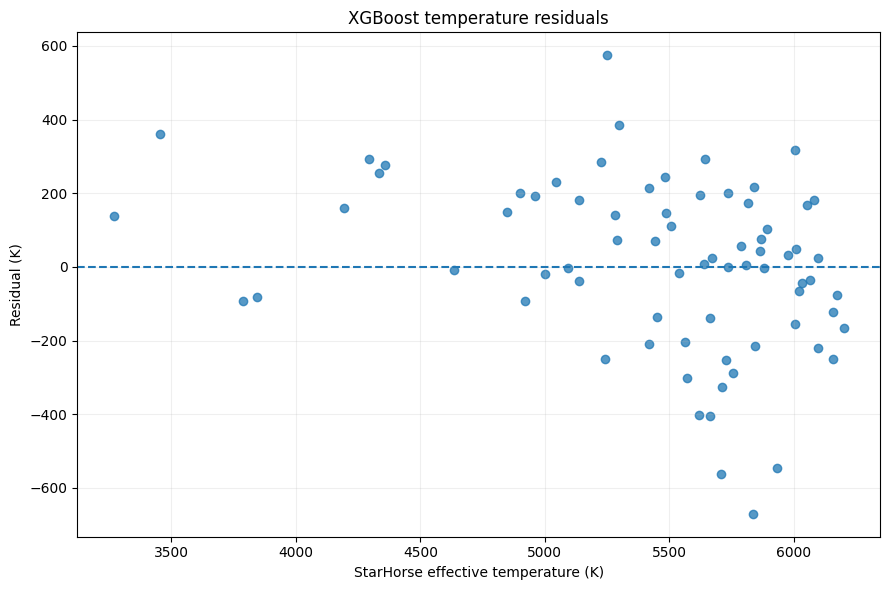

In [8]:
residuals = y_pred - y_test

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test,
    residuals,
    alpha=0.75
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("StarHorse effective temperature (K)")
plt.ylabel("Residual (K)")
plt.title("XGBoost temperature residuals")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

bp_rp              0.708147
parallax           0.147515
phot_g_mean_mag    0.144338
dtype: float32


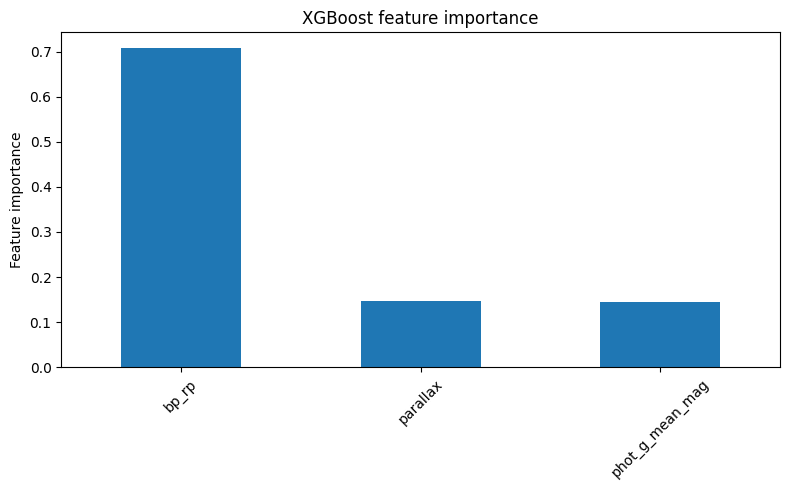

In [9]:
importance = pd.Series(
    model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8, 5))

importance.plot(kind="bar")

plt.ylabel("Feature importance")
plt.title("XGBoost feature importance")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()